In [1]:
import subprocess
import sys
import re
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp
import pandas as pd
import numpy as np


In [2]:
import spacehub_calc
testdf = spacehub_calc.load_spacehub_data("tutorial/Post-Newtonian-up-to-2p5.txt")

<Axes: xlabel='time', ylabel='v'>

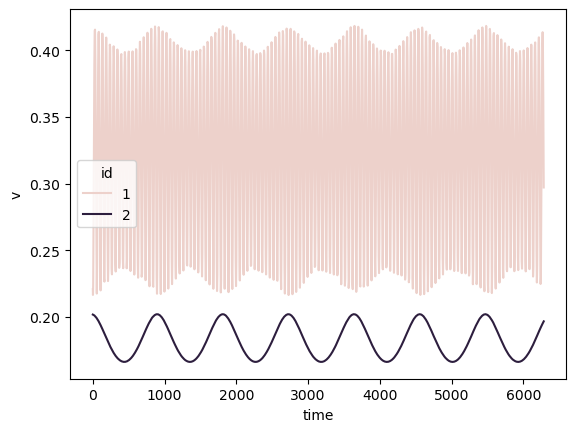

In [3]:
sns.lineplot(testdf[testdf["id"]>0], x="time", y="v", hue="id")

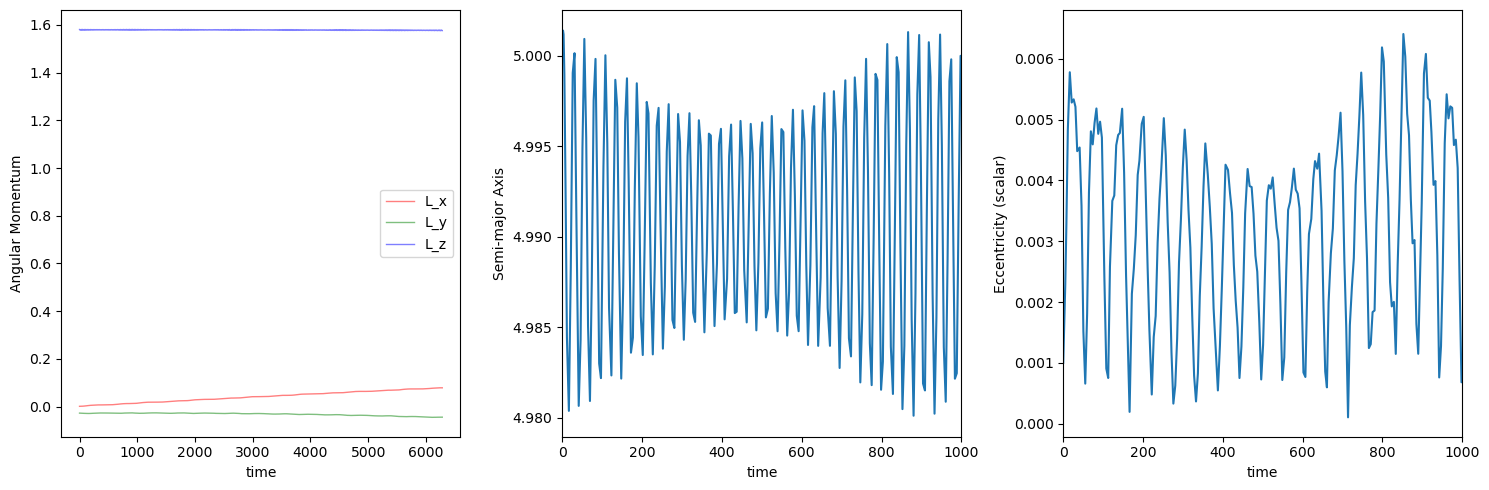

In [33]:
eccvec12 = spacehub_calc.get_ecc(testdf, 0, 1)
a12 = spacehub_calc.get_sma(testdf,0, 1)
L12x, L12y, L12z = spacehub_calc.get_L(testdf,0, 1)

t = testdf["time"].drop_duplicates()

df01 = pd.DataFrame(index=t)
df01["L_x"] = L12x
df01["L_z"] = L12z 
df01["L_y"] = L12y
df01["Semi-major Axis"] = a12
df01["Eccentricity (scalar)"] = spacehub_calc.get_ecc_scalar(testdf,0, 1)
f, axes = plt.subplots(1, 3, figsize=(15, 5))
axs = axes.flatten()

sns.lineplot(data=df01, x="time", y="L_x", ax=axs[0], color='red', label='L_x', lw=1, alpha=0.5)
sns.lineplot(data=df01, x="time", y="L_y", ax=axs[0], color='green', label='L_y', lw=1, alpha=0.5)
sns.lineplot(data=df01, x="time", y="L_z", ax=axs[0], color='blue', label='L_z', lw=1, alpha=0.5)

axs[0].set_ylabel("Angular Momentum")

sns.lineplot(data=df01, x="time", y="Semi-major Axis", ax=axs[1])
axs[1].set_xlim(0, 1000)
sns.lineplot(data=df01, x="time", y="Eccentricity (scalar)", ax=axs[2])
axs[2].set_xlim(0,1000)

f.tight_layout()